Loading scenario Run_309


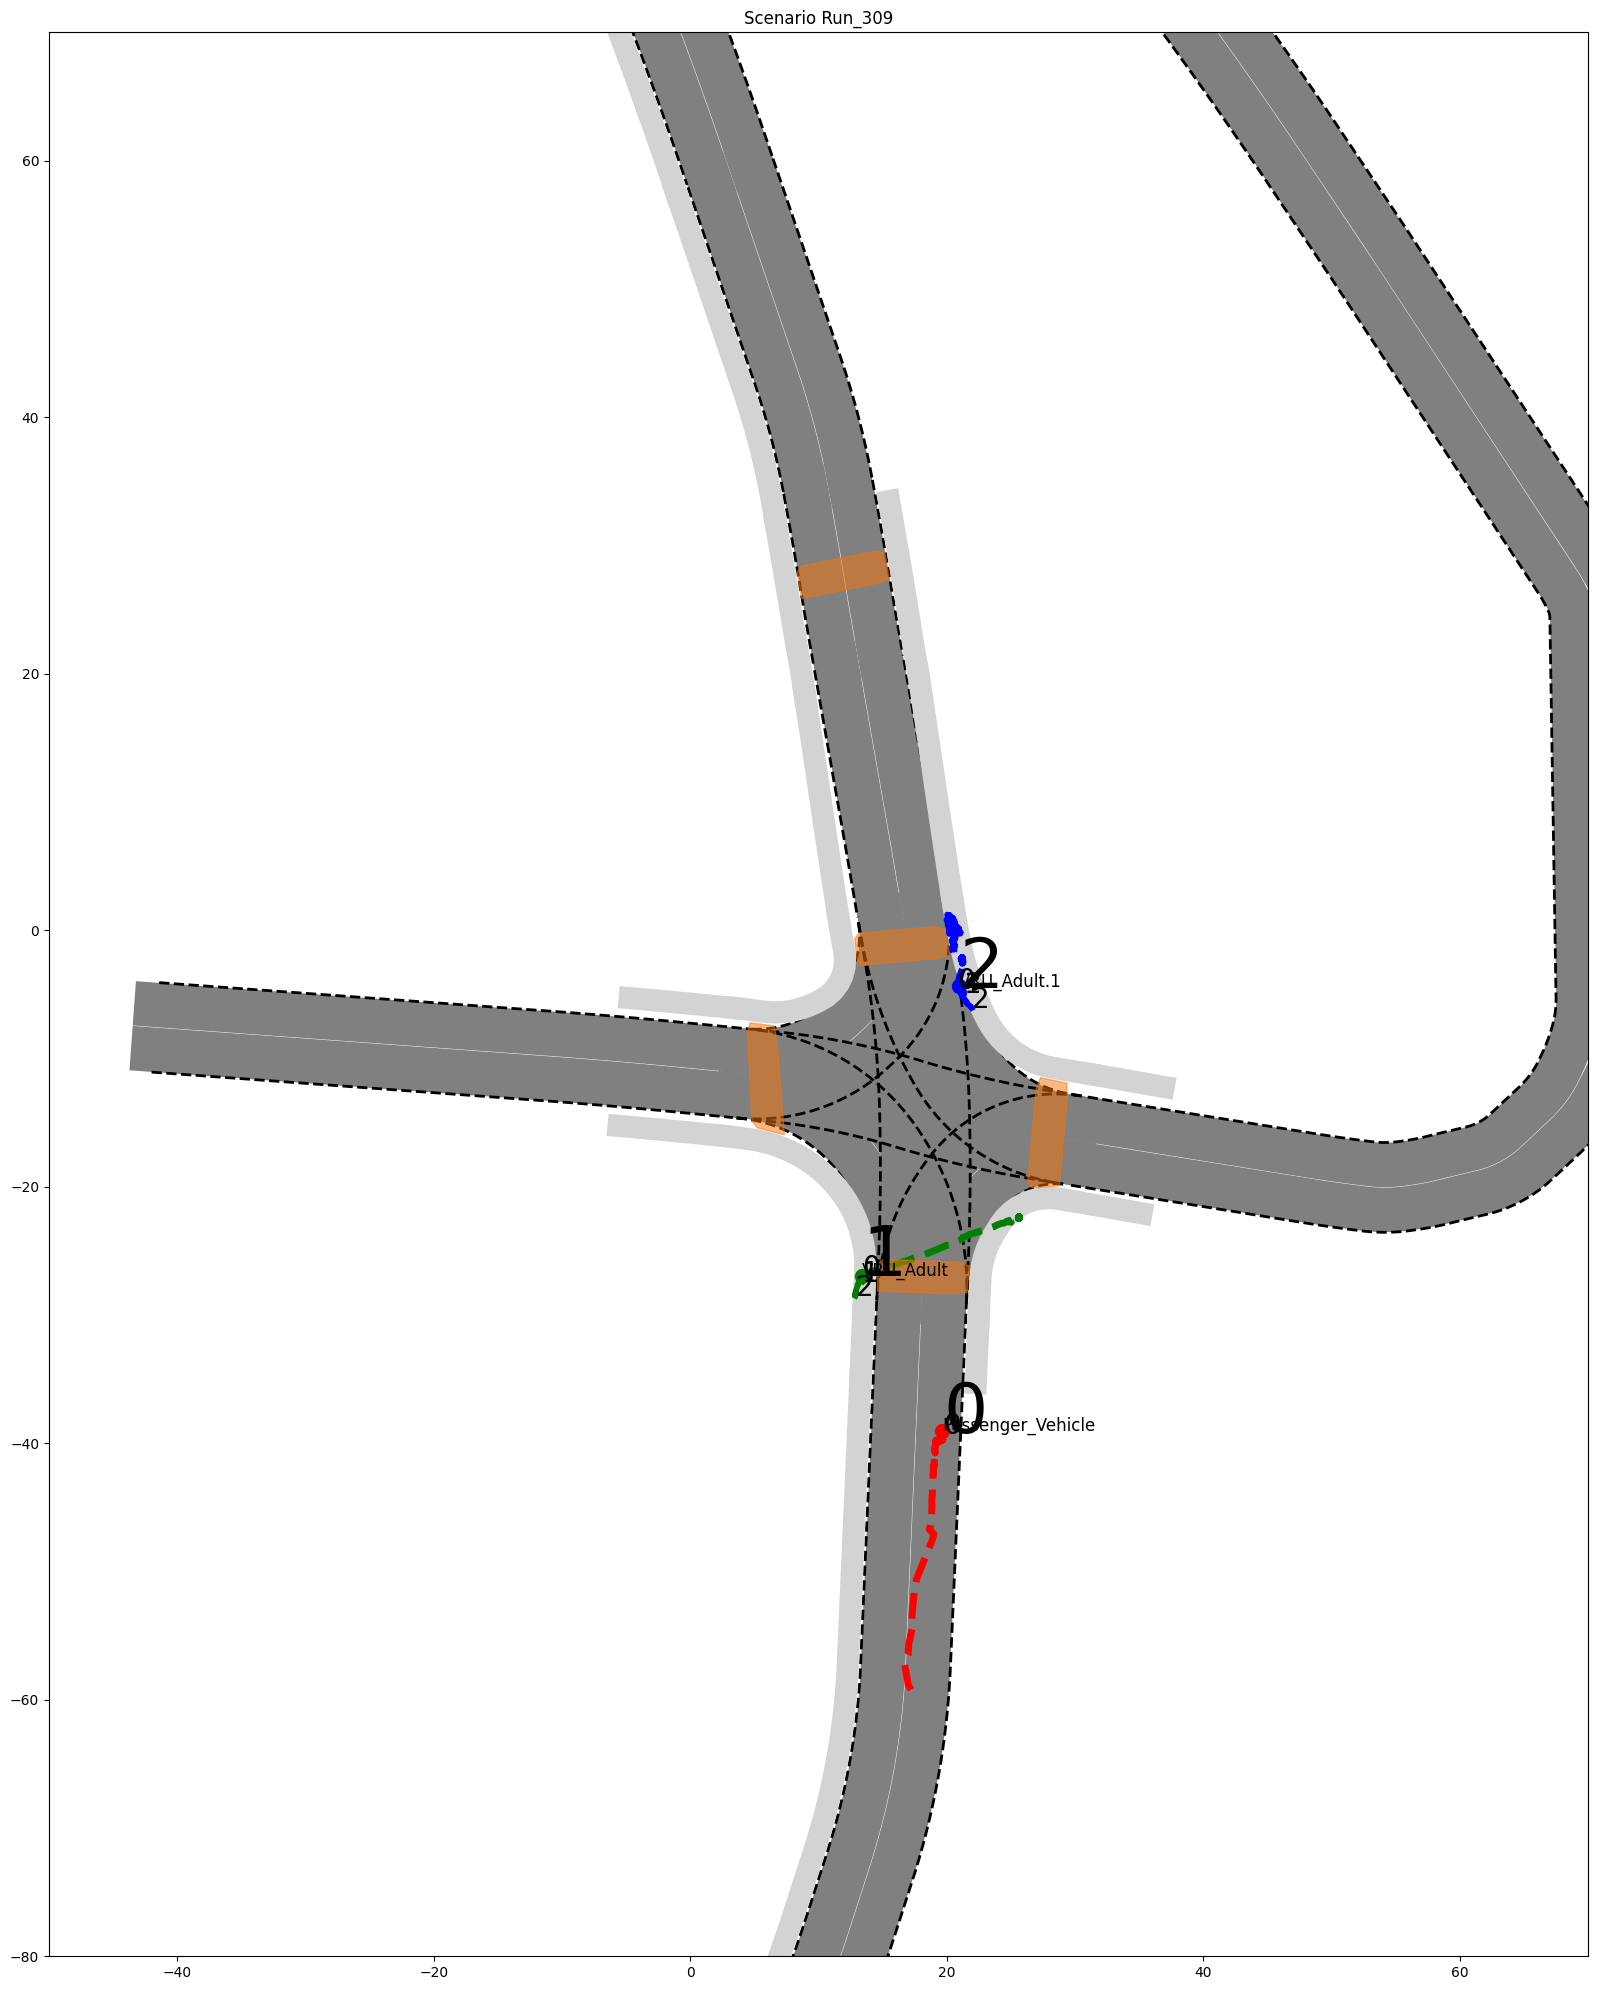

You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)
You can input 'n' to cancel the wrong input
Keeping the original predictions
Loading scenario Run_326


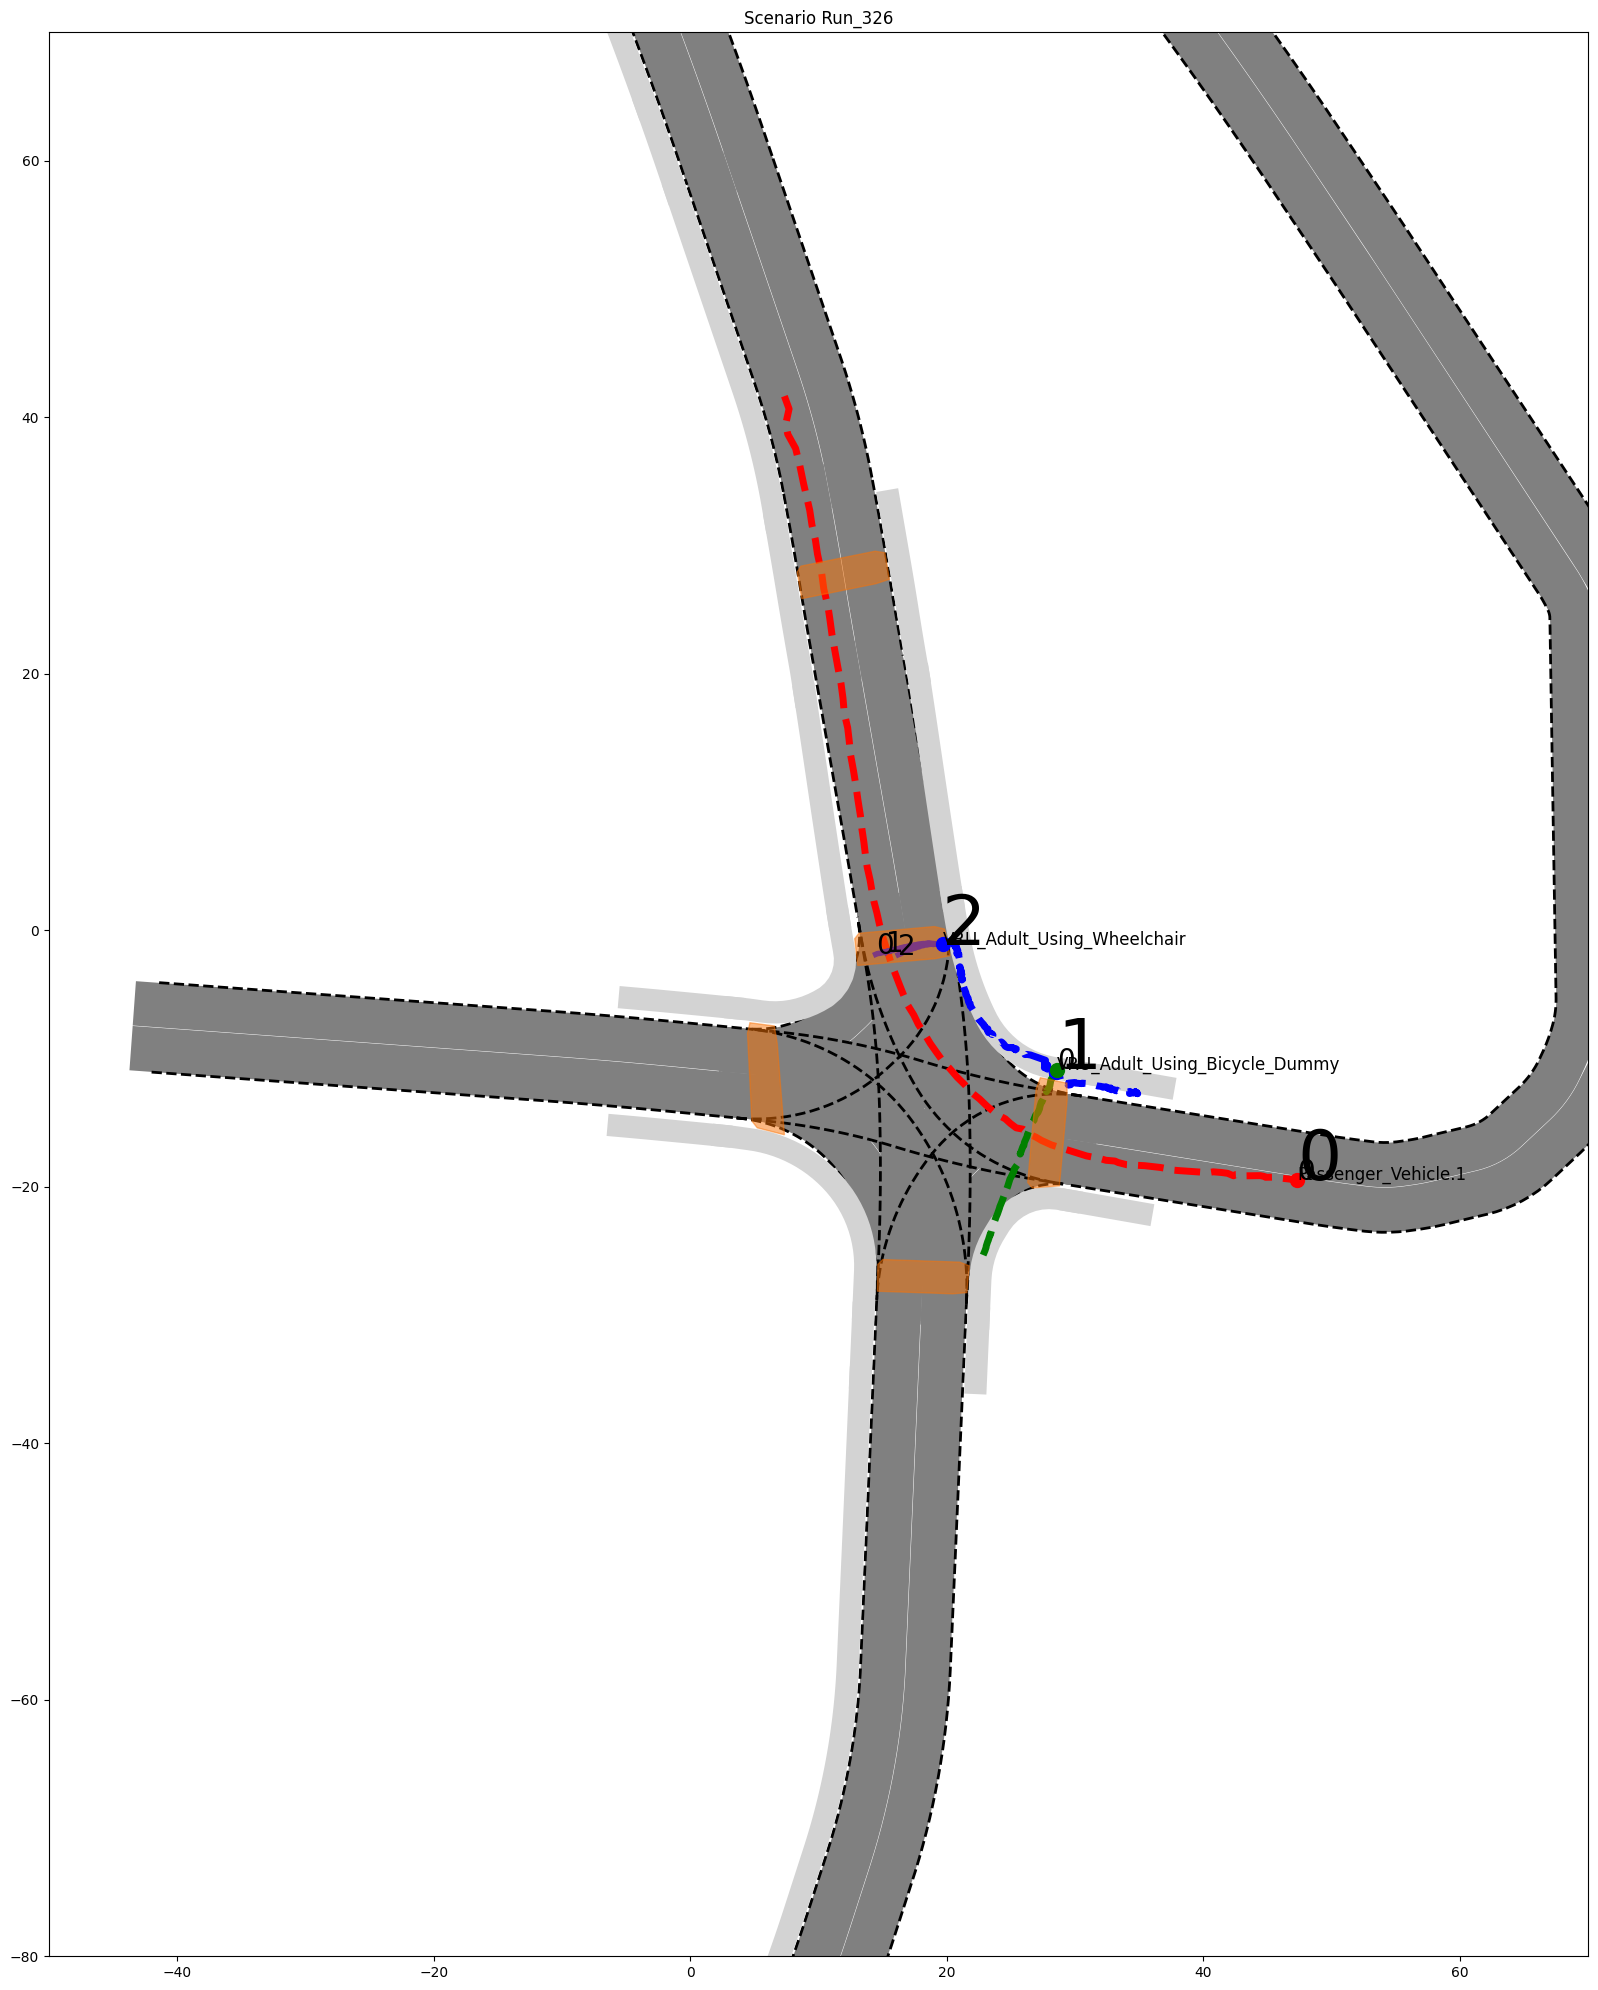

You can input 'n' to cancel the wrong input
Keeping the original predictions
Loading scenario Run_252


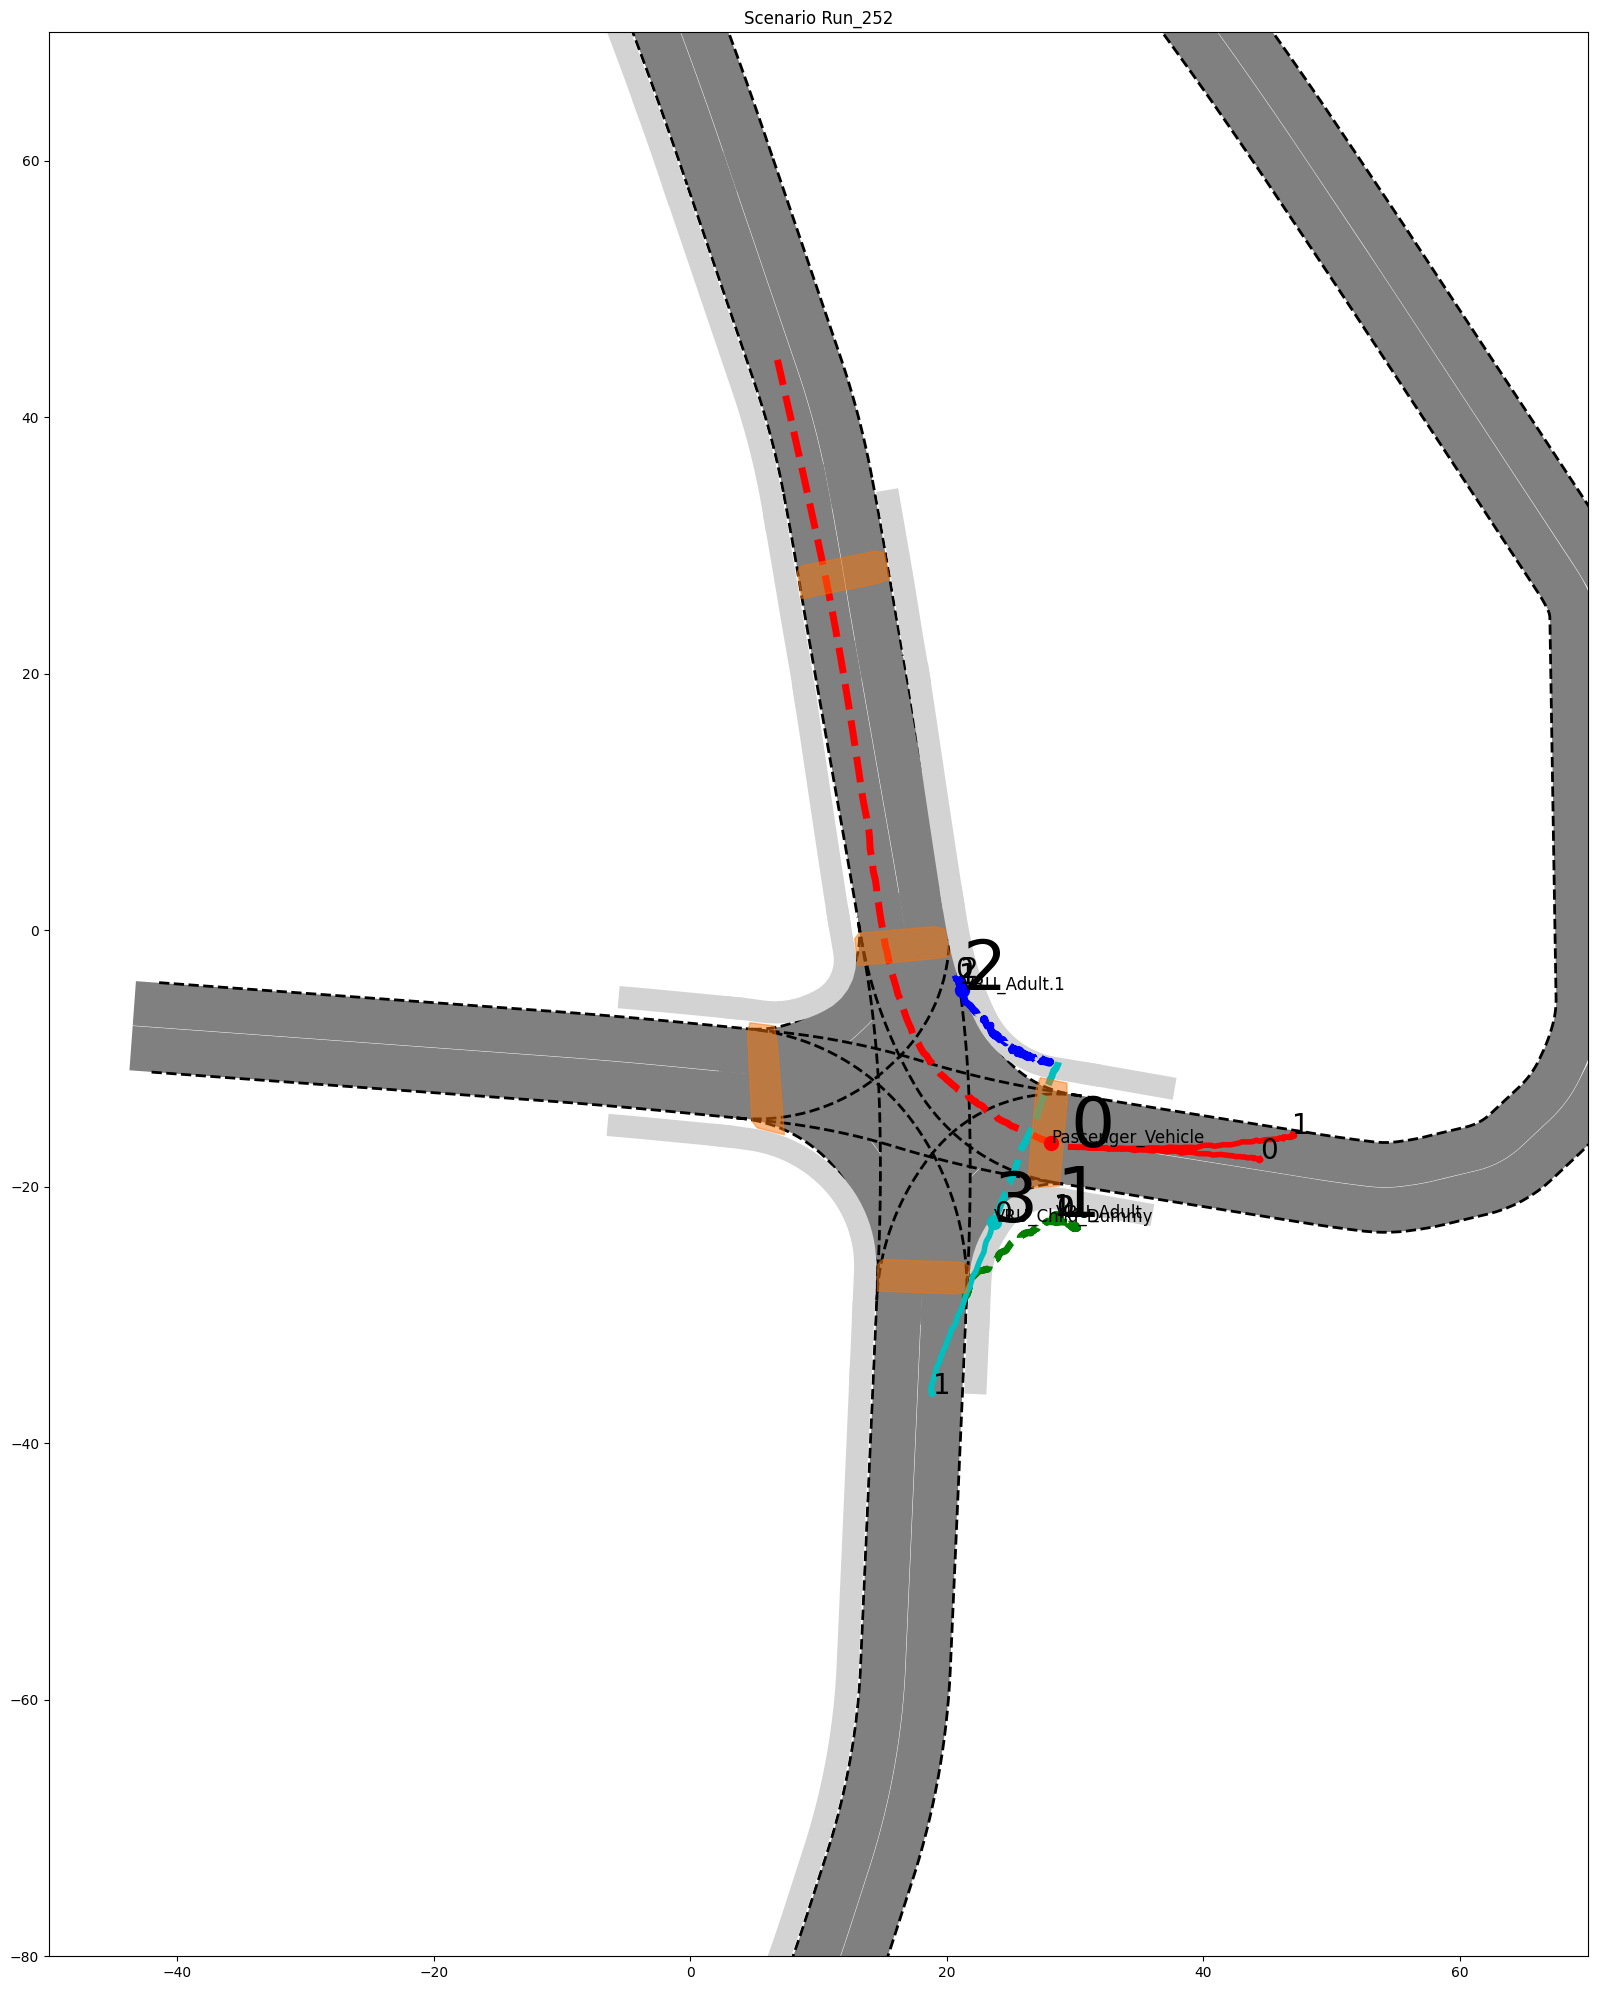

You can input 'n' to cancel the wrong input
Keeping the original predictions
Loading scenario Run_63


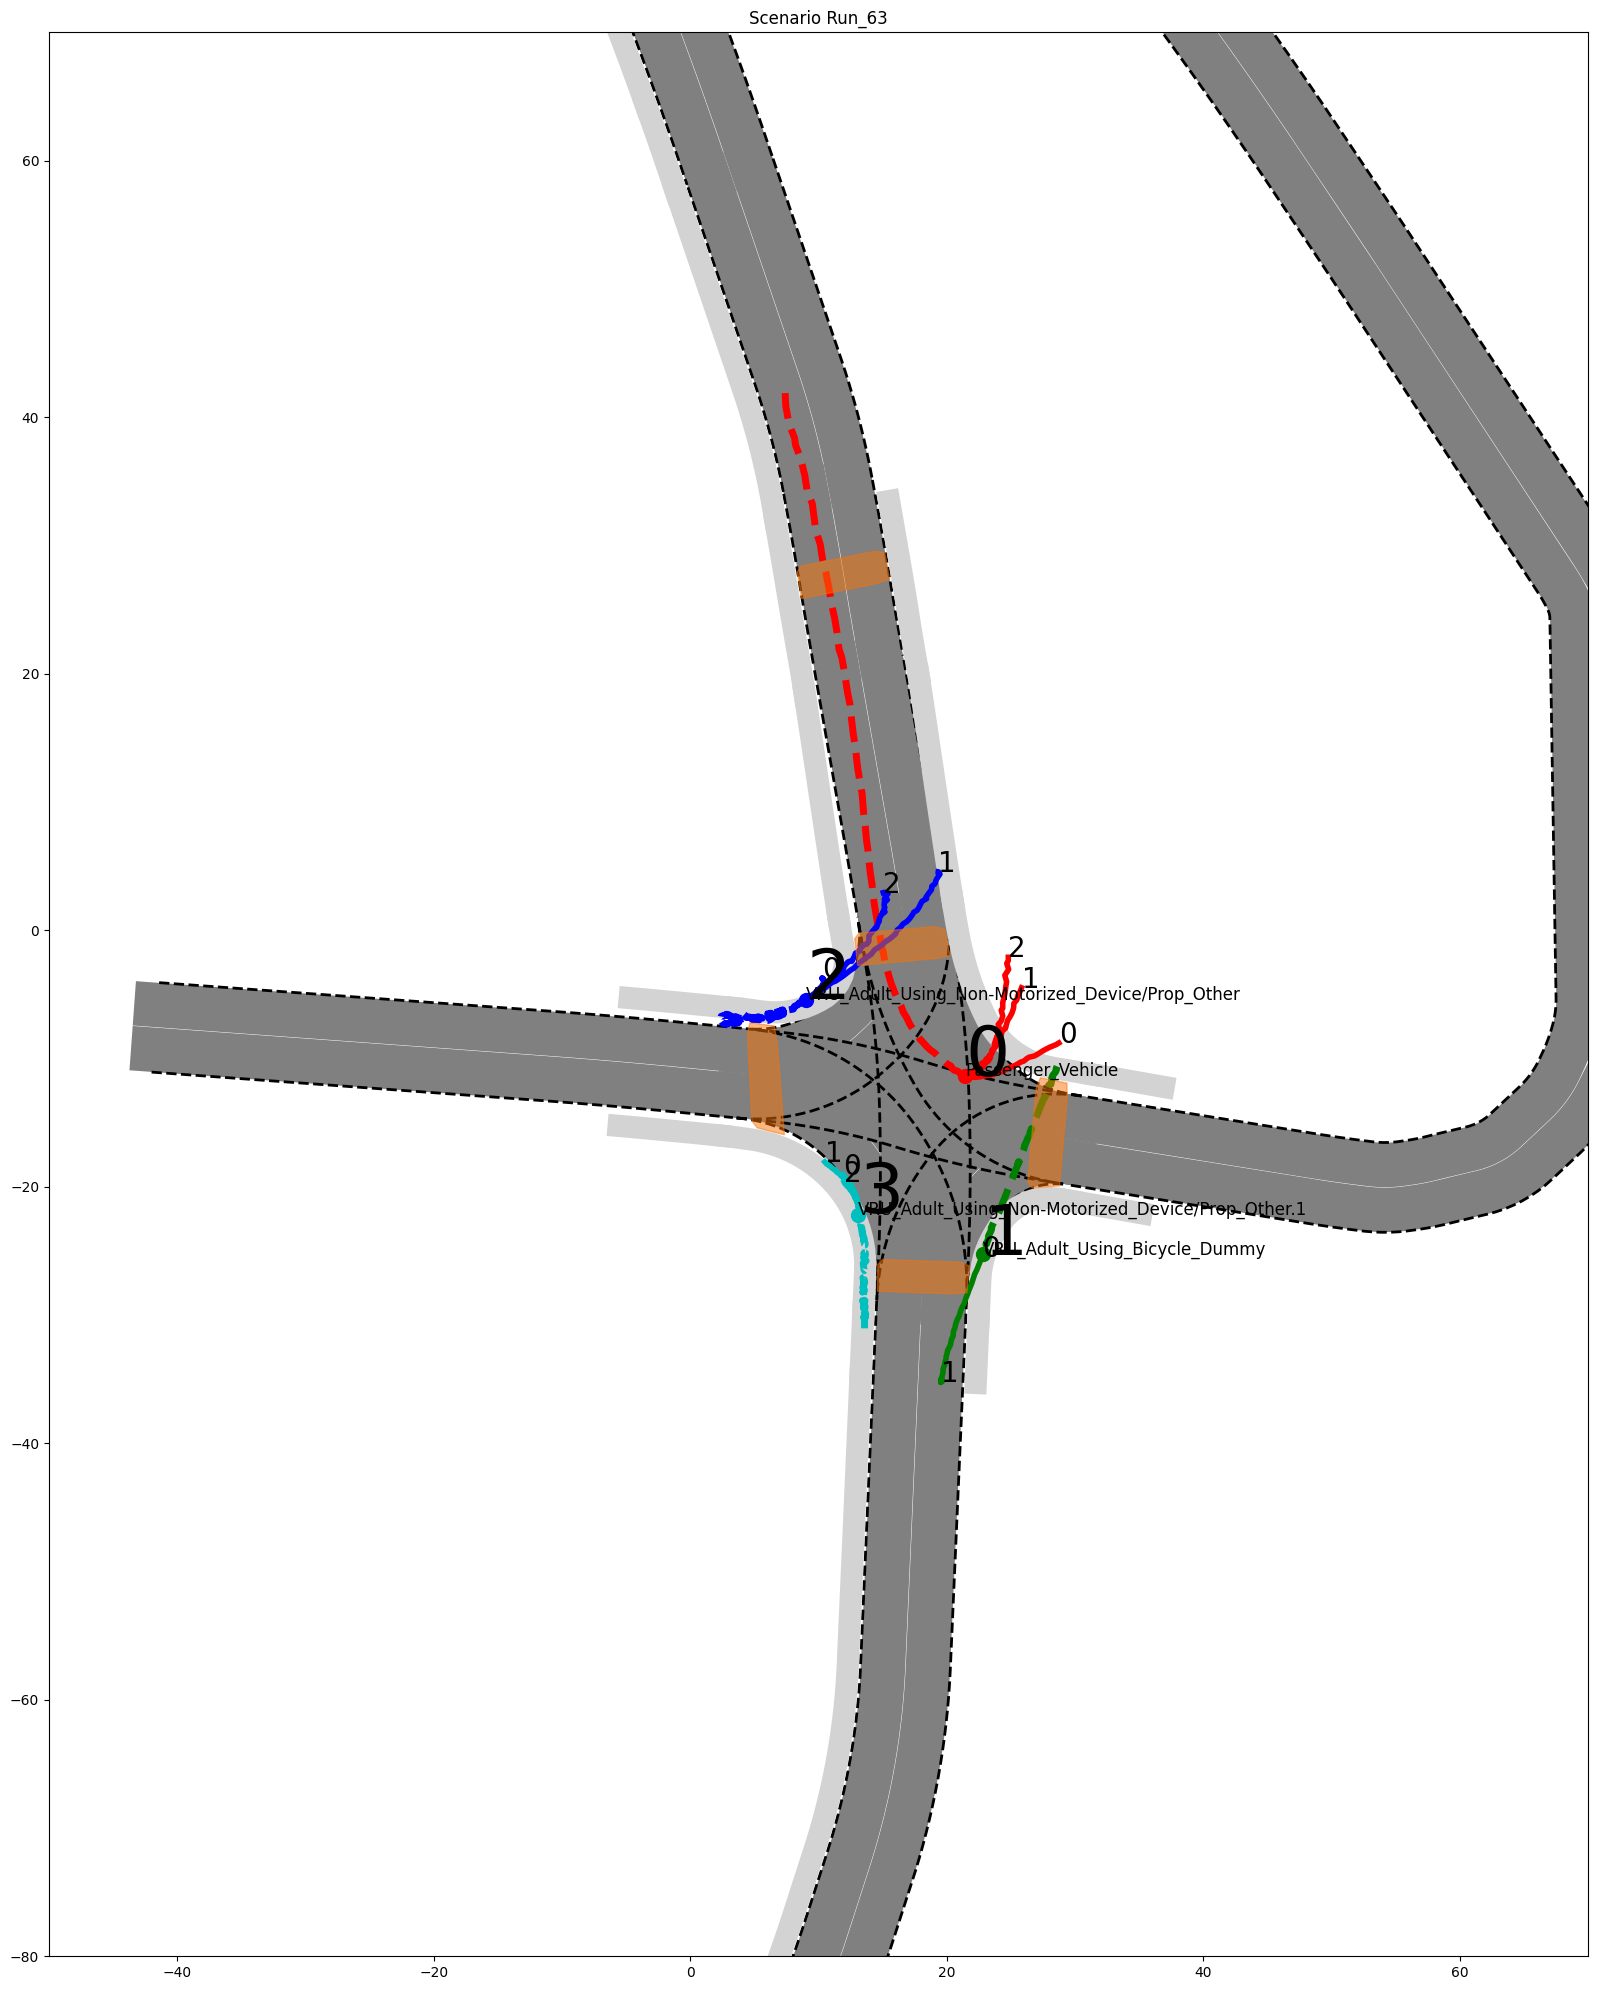

You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)
You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)
You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)
You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)
You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)
You can input 'n' to cancel the wrong input
Please enter a valid response (y/n)


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from test_utils import *
from data_utils import *

# Load the data
results_path = "mtr_result_rehearsal_3"
results_files = glob.glob(results_path + "/*.csv")
trajectory_path = "../Data/rehearsal_3"
trajectory_files = glob.glob(trajectory_path + "/*.csv")
final_results_path = "mtr_result_rehearsal_3_Final_Results"
os.makedirs(final_results_path, exist_ok=True)


# Functions
def write_to_csv(data, timesteps, filename):
    """
    Write the data to a csv file.
    
    Args:
        data: the data to write (Dictionary of trajectories)
        timesteps: time steps
        filename: the filename to write to csv
    """
    with open(os.path.join(final_results_path, filename), 'w') as f:
        f.write("Timestamps,ID,subclass,path_ID,x_center,y_center,z_center,x_length,y_length,z_length,confidence_score\n")
        for i, time in enumerate(timesteps):
            for j, agent in enumerate(data):
                for k, trajectory in enumerate(data[agent][0]):
                    t = time
                    id = data[agent][2]
                    sub_class = data[agent][3]
                    path_ID = k + 1
                    x_center = trajectory[i][0]
                    y_center = trajectory[i][1]
                    z_center = trajectory[i][2]
                    x_length = trajectory[i][3]
                    y_length = trajectory[i][4]
                    z_length = trajectory[i][5]
                    confidence_score = data[agent][1][k] / np.sum(data[agent][1])
                    f.write(f"{t},{id},{sub_class},{path_ID},{x_center},{y_center},{z_center},{x_length},{y_length},{z_length},{confidence_score}\n")

    # reorder csv file based on the path_ID
    df = pd.read_csv(os.path.join(final_results_path, filename))
    df = df.sort_values(by=['ID', 'path_ID'])
    df = df.drop(columns=['ID'])
    df.to_csv(os.path.join(final_results_path, filename), index=False)


def generate_trajectory(points, start):
    """
    Generate a trajectory based on the points and time steps.
    
    Args:
        points: the points to generate the trajectory
        time_steps: the time steps to generate the trajectory
    
    Returns:
        the generated trajectory
    """
    # Generate the trajectory
    time_steps = [0.0, 1.0, 3.0, 5.0]
    trajectory_time = np.linspace(0, 5, 51)

    # interpolate the points
    x = [start[0]] + [p[0] for p in points]
    y = [start[1]] + [p[1] for p in points]
    f_x = interpolate.interp1d(time_steps, x, kind='cubic')
    f_y = interpolate.interp1d(time_steps, y, kind='cubic')
    new_x = f_x(trajectory_time)
    new_y = f_y(trajectory_time)
    trajectory = np.stack([new_x, new_y], axis=1)
    trajectory = trajectory[1:]
    
    return trajectory


# Go through all the files and load the data
for file in results_files:
    r = pd.read_csv(file)
    scenario_id = file.split('/')[-1].split('_')[0] + '_' + file.split('/')[-1].split('_')[1]
    print(f"Loading scenario {scenario_id}")
    time_steps = r['Timestamps'].unique()

    # load the trajectory data
    trajectory_file = [f for f in trajectory_files if scenario_id in f][0]
    trajectory_data = pd.read_csv(trajectory_file)
    trajectory_data = trajectory_data[trajectory_data['Time'] < time_steps[0]]
    if len(trajectory_data) == 0:
        print(f"No ground truth data for scenario {scenario_id}")
        continue

    csv_keygroup = get_object_keygroups(trajectory_data)

    history_trajectory_data = {}
    for key, group in csv_keygroup.items():
        id = key.replace('_xctr', '')
        x = trajectory_data[group[0]].values
        y = trajectory_data[group[1]].values
        traj = np.stack([x, y], axis=1)
        history_trajectory_data[id] = traj

    # visualize the trajectory data
    plt.close()
    plt.figure(figsize=(20, 20))
    plot_vector_map()

    colors = ['r', 'g', 'b', 'c', 'm']
    agents = r['ID'].unique()
    trajectories = {}
    agent_starts = {}

    for a_i, a in enumerate(agents):
        agent_data = r[r['ID'] == a]
        trajectory_data = [agent_data[id==agent_data['path_ID']] for id in agent_data['path_ID'].unique()]
        trajectory_data_array = [np.array([t['x_center'], t['y_center'],
                                           t['z_center'], t['x_length'],
                                           t['y_length'], t['z_length']]).T for t in trajectory_data]
        trajectory_confidence = [np.array(t['confidence_score'])[0] for t in trajectory_data]
        agent_start = history_trajectory_data[a][-1]
        agent_starts[a_i] = agent_start

        plot_agent(agent_start, a, color=colors[a_i])
        plot_trajectory(history_trajectory_data[a], color=colors[a_i], history=True)
        plot_trajectory(trajectory_data_array, color=colors[a_i])
        trajectories[a_i] = (trajectory_data_array, trajectory_confidence, a, agent_data['subclass'].values[0])
        plt.text(trajectory_data_array[0][0][0], trajectory_data_array[0][0][1], str(a_i), fontsize=50, color='black', zorder=5)

    plt.title(f'Scenario {scenario_id}')
    plt.xlim(-50, 70)
    plt.ylim(-80, 70)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show(block=False)

    # Prompt the user to determine if human correction is needed
    while True:
        prompt = input("Do you want to adjust the predictions? (y/n): ")
        add_trajectory = False

        print("You can input 'n' to cancel the wrong input")

        if prompt.lower() == 'y':
            prompt = input(f"Which agent do you want to adjust? 0 - {len(trajectories)-1}: ")
            if prompt.lower() == 'n':
                print("Cancel the wrong input")
                continue

            while not prompt.isdigit() or int(prompt) not in range(len(trajectories)):
                prompt = input(f"Please enter a valid number between 0 and {len(trajectories)-1}: ")
            
            agent = trajectories[int(prompt)]
            print(f"Adjusting agent {agent[2]}")

            # Prompt the user to add or remove a trajectory
            prompt = input(f"Which trajectory do you want to remove? 0 - {len(agent[0])-1}: ")
            if prompt.lower() == 'n':
                print("Cancel the wrong input")
                continue

            while not prompt.isdigit() or int(prompt) not in range(len(agent[0])):
                prompt = input(f"Please enter a valid number between 0 and {len(agent[0])-1}: ")
      
            # keep other variables
            z_center = agent[0][0][:, 2:3]
            x_length = agent[0][0][:, 3:4]
            y_length = agent[0][0][:, 4:5]
            z_length = agent[0][0][:, 5:6]

            # Remove the selected trajectory
            agent[0].pop(int(prompt))
            agent[1].pop(int(prompt))

            # plot the new scenario
            plt.close()
            plt.figure(figsize=(20, 20))
            plot_vector_map()
            colors = ['r', 'g', 'b', 'c', 'm']

            for a_i, a in enumerate(trajectories):
                plot_agent(agent_starts[a_i], trajectories[a_i][2], color=colors[a_i])
                plot_trajectory(history_trajectory_data[trajectories[a_i][2]], color=colors[a_i], history=True)

                # skip if there are no trajectories left
                if trajectories[a_i][0] == []:
                    add_trajectory = True
                    agent_id = a_i
                    continue 
                
                plot_trajectory(trajectories[a_i][0], color=colors[a_i])
                plt.text(trajectories[a_i][0][0][0][0], trajectories[a_i][0][0][0][1], str(a_i), fontsize=50, color='black', zorder=5)

            plt.title(f'Scenario {scenario_id}')
            plt.xlim(-50, 70)
            plt.ylim(-80, 70)
            plt.gca().set_aspect('equal', adjustable='box')
            plt.tight_layout()
            plt.show(block=False)

            if add_trajectory:
                print(f"Pleses add a new trajectory by selecting four points on the map for {trajectories[agent_id][2]}")
                input("Please adjust the view and press enter to continue")
                new_trajectory = []

                for i in range(3):
                    x, y = plt.ginput(1)[0]
                    new_trajectory.append([x, y])
                    plt.scatter(x, y, color=colors[agent_id], s=100, zorder=4)
                    plt.text(x, y, f"{2*i+1} s", fontsize=20, color='black', zorder=5)
                
                new_trajectory_xy_center = generate_trajectory(new_trajectory, agent_starts[agent_id])
                new_trajectory = np.concatenate([new_trajectory_xy_center, z_center, x_length, y_length, z_length], axis=1)
                trajectories[agent_id][0].append(new_trajectory)
                trajectories[agent_id][1].append(1.0)

                plot_trajectory([new_trajectory], color=colors[agent_id]) # plot the new trajectory
                plt.text(40, -40, 'New trajectory added!', fontsize=40, color='black', zorder=5)
                plt.show(block=False)

        # keep the original predictions
        elif prompt.lower() == 'n': 
            print("Keeping the original predictions")
            write_to_csv(trajectories, time_steps, file.split('/')[-1])
            break

        else:
            print("Please enter a valid response (y/n)")
            continue